# EF-02: Financial News Sentiment Analyser — Visualization Notebook
**BSc DSAI | Tanzania Financial Sector Projects | 2025/2026**

This notebook visualizes the monthly aggregated sentiment data alongside BOT inflation and USD/TZS exchange rate data for 2022–2024.

> **Note:** The current dataset has a known labelling bias — the majority of monthly aggregates are Neutral. This is expected to be resolved upon re-scraping and re-labelling with the Groq-based pipeline.

## 1. Setup & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Simple, clean style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

# Sentiment colour palette used consistently across all plots
SENTIMENT_COLORS = {
    'Positive': '#2196F3',   # blue
    'Neutral':  '#9E9E9E',   # grey
    'Negative': '#F44336',   # red
}

In [2]:
df = pd.read_csv('data/Visualization_Data.csv')

# Parse YearMonth to proper datetime
df['Date'] = pd.to_datetime(df['YearMonth'], format='%Y-%m')
df = df.sort_values('Date').reset_index(drop=True)

# Quick sanity check
print(f'Rows: {len(df)}   |   Period: {df["YearMonth"].min()} → {df["YearMonth"].max()}')
df.head()

Rows: 35   |   Period: 2022-01 → 2024-11


,YearMonth,num_headlines,Top_Category,category %,Negative %,Neutral %,Positive %,Dominant_Sentiment,Inflation %,USD/TZS_Rate,Rate_Change_%,Date
0,2022-01,43,General,37.21,16.28,62.79,20.93,Neutral,3.997044,2303.380952,0.000000,2022-01-01
1,2022-02,33,General,24.24,9.09,60.61,30.30,Neutral,3.673581,2308.800000,0.235265,2022-02-01
2,2022-03,45,General,35.56,8.89,71.11,20.00,Neutral,3.552367,2312.565217,0.163081,2022-03-01
3,2022-04,41,General,24.39,17.07,46.34,36.59,Neutral,3.783246,2317.761905,0.224715,2022-04-01
4,2022-05,44,General,22.73,15.91,40.91,43.18,Positive,4.026812,2320.818182,0.131863,2022-05-01


---
## 2. Dataset Overview

### 2.1 Monthly Headline Counts (2022–2024)

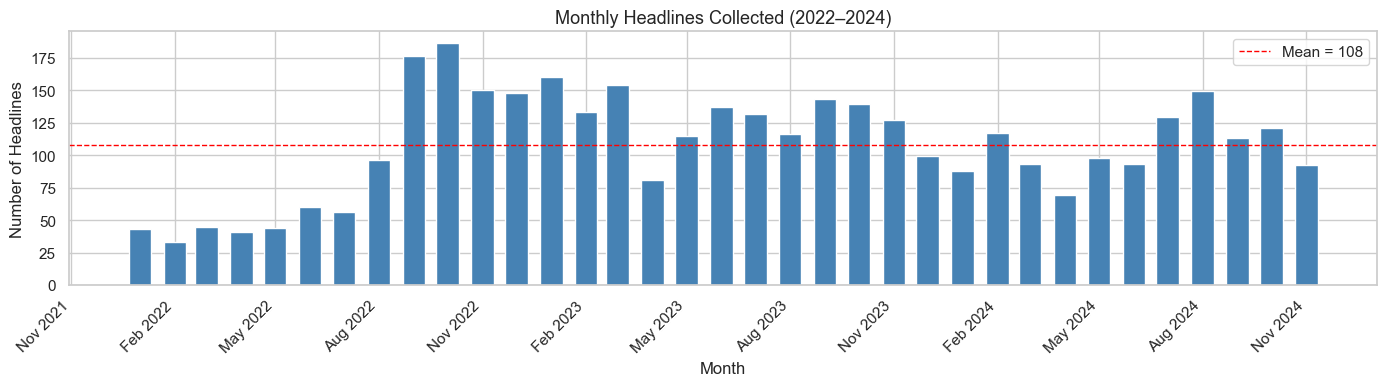

Total headlines: 3,776   |   Monthly mean: 108


In [3]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.bar(df['Date'], df['num_headlines'], color='steelblue', width=20)
ax.set_title('Monthly Headlines Collected (2022–2024)', fontsize=13)
ax.set_xlabel('Month')
ax.set_ylabel('Number of Headlines')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha='right')

# Annotate mean
mean_val = df['num_headlines'].mean()
ax.axhline(mean_val, color='red', linestyle='--', linewidth=1, label=f'Mean = {mean_val:.0f}')
ax.legend()

plt.tight_layout()
plt.show()
print(f'Total headlines: {df["num_headlines"].sum():,}   |   Monthly mean: {mean_val:.0f}')

### 2.2 Dominant Top Category per Month

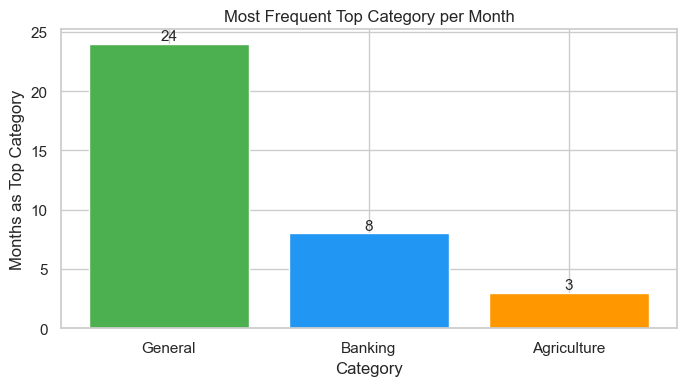

In [4]:
cat_counts = df['Top_Category'].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(cat_counts.index, cat_counts.values, color=['#4CAF50', '#2196F3', '#FF9800'])
ax.set_title('Most Frequent Top Category per Month')
ax.set_xlabel('Category')
ax.set_ylabel('Months as Top Category')

for i, v in enumerate(cat_counts.values):
    ax.text(i, v + 0.3, str(v), ha='center', fontsize=11)

plt.tight_layout()
plt.show()

---
## 3. Sentiment Analysis

### 3.1 Sentiment Distribution — Stacked Bar (Monthly)

> ⚠️ The high Neutral dominance across months is a known data quality issue. The current labelling pipeline (Groq API) produced predominantly Neutral scores. Re-labelling after re-scraping is the next step.

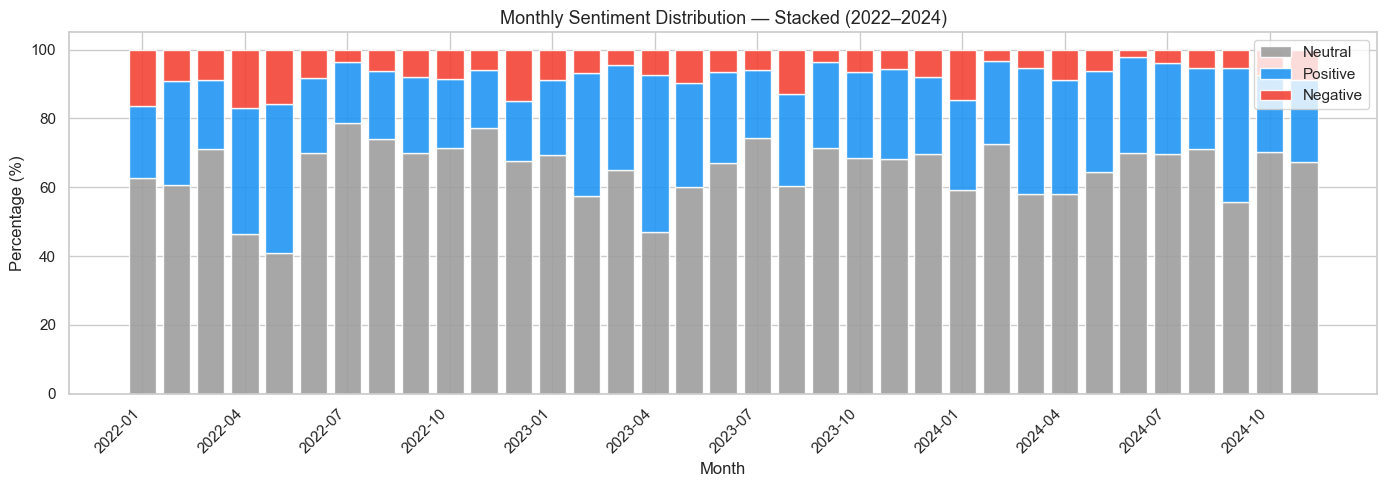

In [5]:
fig, ax = plt.subplots(figsize=(14, 5))

x = np.arange(len(df))
ax.bar(x, df['Neutral %'],  label='Neutral',  color=SENTIMENT_COLORS['Neutral'],  alpha=0.9)
ax.bar(x, df['Positive %'], label='Positive', color=SENTIMENT_COLORS['Positive'], alpha=0.9,
       bottom=df['Neutral %'])
ax.bar(x, df['Negative %'], label='Negative', color=SENTIMENT_COLORS['Negative'], alpha=0.9,
       bottom=df['Neutral %'] + df['Positive %'])

ax.set_title('Monthly Sentiment Distribution — Stacked (2022–2024)', fontsize=13)
ax.set_xlabel('Month')
ax.set_ylabel('Percentage (%)')
ax.set_xticks(x[::3])
ax.set_xticklabels(df['YearMonth'].iloc[::3], rotation=45, ha='right')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

### 3.2 Positive vs Negative Sentiment Over Time

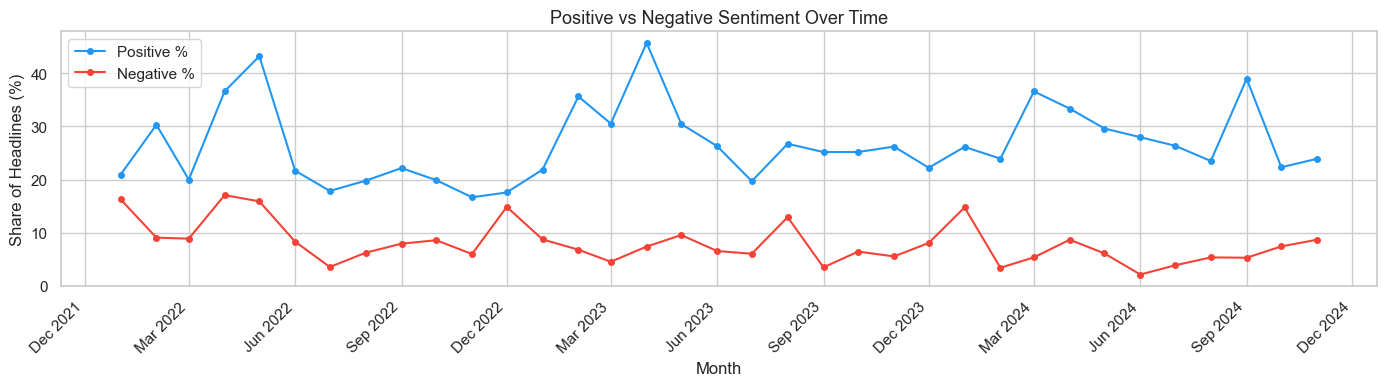

In [6]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df['Date'], df['Positive %'], color=SENTIMENT_COLORS['Positive'],
        marker='o', markersize=4, linewidth=1.5, label='Positive %')
ax.plot(df['Date'], df['Negative %'], color=SENTIMENT_COLORS['Negative'],
        marker='o', markersize=4, linewidth=1.5, label='Negative %')

ax.set_title('Positive vs Negative Sentiment Over Time', fontsize=13)
ax.set_xlabel('Month')
ax.set_ylabel('Share of Headlines (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.show()

### 3.3 Sentiment Score — Net Positivity Index
A simple composite: `Positive % − Negative %`. Positive values indicate net optimistic months.

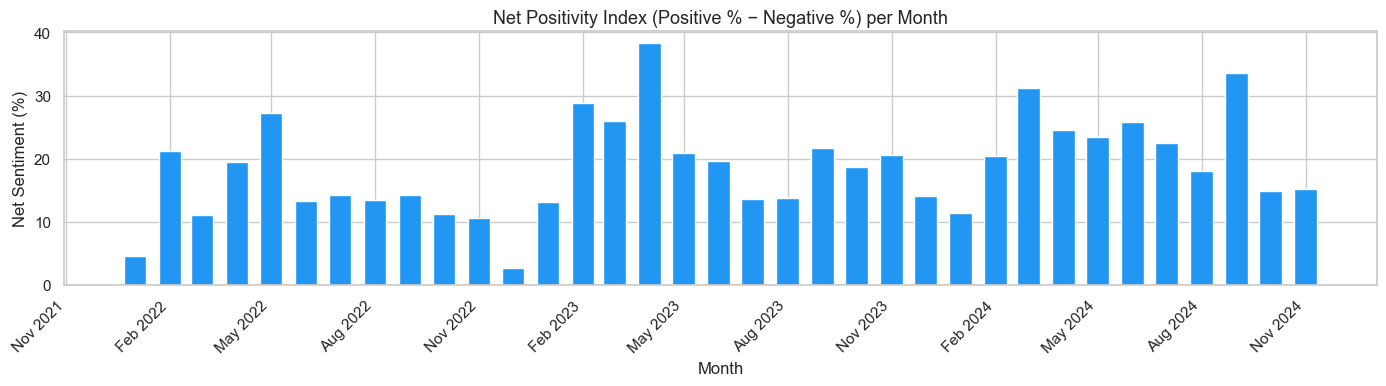

Most positive month:  2023-04  (38.3%)
Most negative month:  2022-12  (2.7%)


In [7]:
df['Net_Sentiment'] = df['Positive %'] - df['Negative %']

fig, ax = plt.subplots(figsize=(14, 4))

colors = [SENTIMENT_COLORS['Positive'] if v >= 0 else SENTIMENT_COLORS['Negative']
          for v in df['Net_Sentiment']]

ax.bar(df['Date'], df['Net_Sentiment'], color=colors, width=20)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

ax.set_title('Net Positivity Index (Positive % − Negative %) per Month', fontsize=13)
ax.set_xlabel('Month')
ax.set_ylabel('Net Sentiment (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

print(f'Most positive month:  {df.loc[df["Net_Sentiment"].idxmax(), "YearMonth"]}  '
      f'({df["Net_Sentiment"].max():.1f}%)')
print(f'Most negative month:  {df.loc[df["Net_Sentiment"].idxmin(), "YearMonth"]}  '
      f'({df["Net_Sentiment"].min():.1f}%)')

---
## 4. Economic Indicators

### 4.1 TZS Inflation Rate Over Time

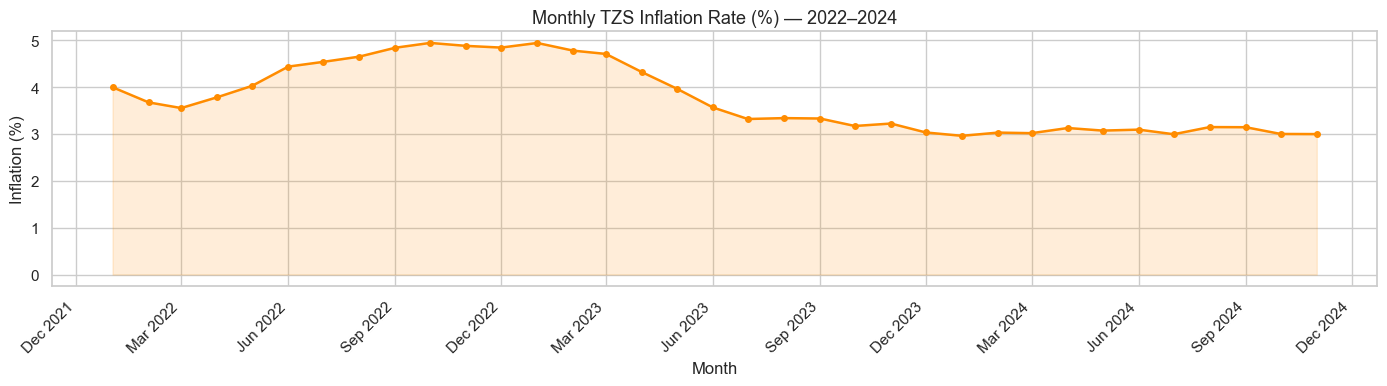

In [8]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df['Date'], df['Inflation %'], color='darkorange', marker='o',
        markersize=4, linewidth=1.8)
ax.fill_between(df['Date'], df['Inflation %'], alpha=0.15, color='darkorange')

ax.set_title('Monthly TZS Inflation Rate (%) — 2022–2024', fontsize=13)
ax.set_xlabel('Month')
ax.set_ylabel('Inflation (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### 4.2 USD/TZS Exchange Rate Over Time

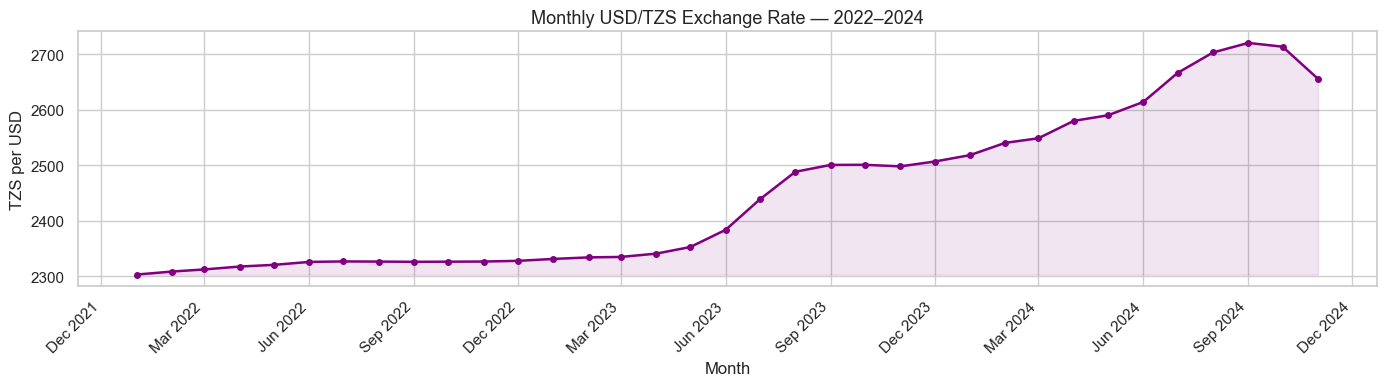

TZS depreciation over the period: 352 TZS/USD  (15.3%)


In [9]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df['Date'], df['USD/TZS_Rate'], color='purple', marker='o',
        markersize=4, linewidth=1.8)
ax.fill_between(df['Date'], df['USD/TZS_Rate'], df['USD/TZS_Rate'].min(),
                alpha=0.1, color='purple')

ax.set_title('Monthly USD/TZS Exchange Rate — 2022–2024', fontsize=13)
ax.set_xlabel('Month')
ax.set_ylabel('TZS per USD')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

depreciation = df['USD/TZS_Rate'].iloc[-1] - df['USD/TZS_Rate'].iloc[0]
print(f'TZS depreciation over the period: {depreciation:.0f} TZS/USD  '
      f'({depreciation / df["USD/TZS_Rate"].iloc[0] * 100:.1f}%)')

---
## 5. Sentiment–Economic Correlation

### 5.1 Dual-Axis: Positive Sentiment vs Inflation

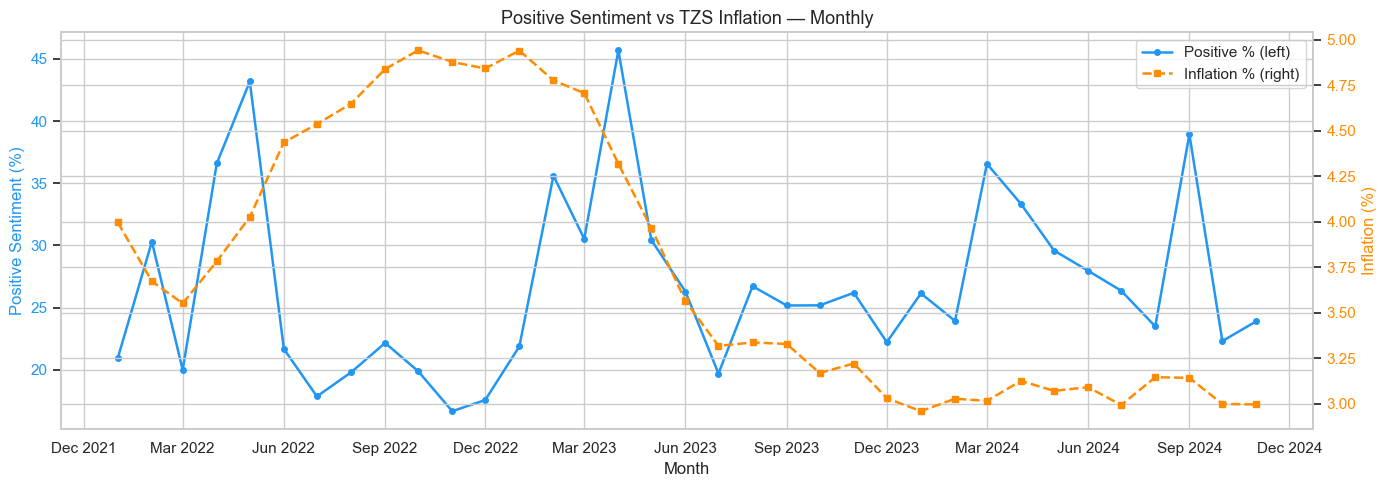

In [11]:
fig, ax1 = plt.subplots(figsize=(14, 5))

# Left axis: Positive sentiment
ax1.plot(df['Date'], df['Positive %'], color=SENTIMENT_COLORS['Positive'],
         linewidth=1.8, marker='o', markersize=4, label='Positive % (left)')
ax1.set_ylabel('Positive Sentiment (%)', color=SENTIMENT_COLORS['Positive'])
ax1.tick_params(axis='y', labelcolor=SENTIMENT_COLORS['Positive'])

# Right axis: Inflation
ax2 = ax1.twinx()
ax2.plot(df['Date'], df['Inflation %'], color='darkorange', linewidth=1.8,
         linestyle='--', marker='s', markersize=4, label='Inflation % (right)')
ax2.set_ylabel('Inflation (%)', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

ax1.set_title('Positive Sentiment vs TZS Inflation — Monthly', fontsize=13)
ax1.set_xlabel('Month')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha='right')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

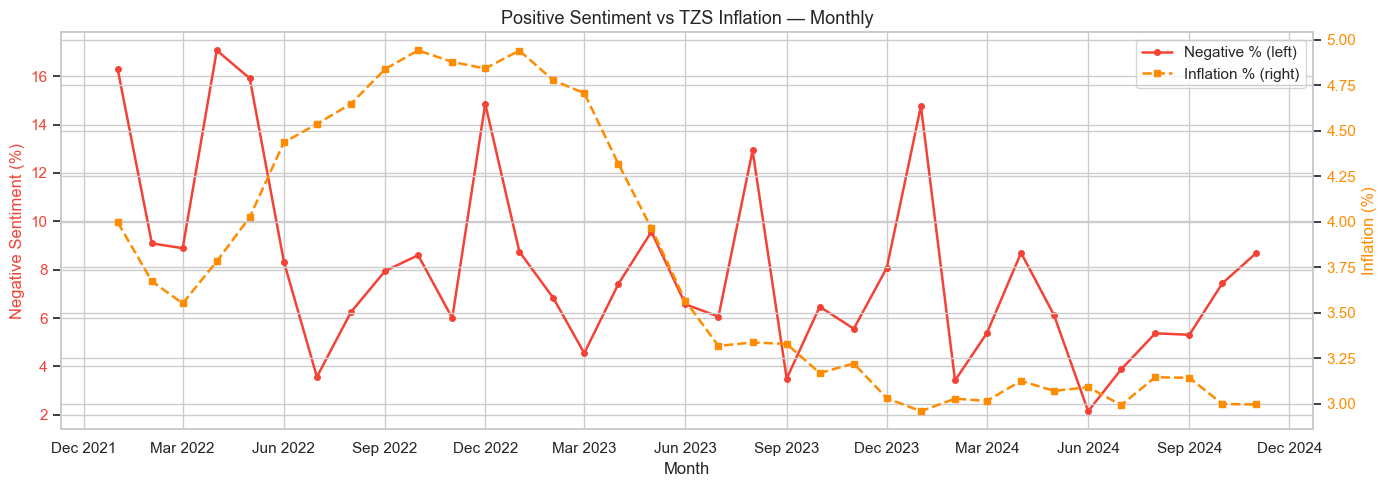

In [12]:
fig, ax1 = plt.subplots(figsize=(14, 5))

# Left axis: Negative sentiment
ax1.plot(df['Date'], df['Negative %'], color=SENTIMENT_COLORS['Negative'],
         linewidth=1.8, marker='o', markersize=4, label='Negative % (left)')
ax1.set_ylabel('Negative Sentiment (%)', color=SENTIMENT_COLORS['Negative'])
ax1.tick_params(axis='y', labelcolor=SENTIMENT_COLORS['Negative'])

# Right axis: Inflation
ax2 = ax1.twinx()
ax2.plot(df['Date'], df['Inflation %'], color='darkorange', linewidth=1.8,
         linestyle='--', marker='s', markersize=4, label='Inflation % (right)')
ax2.set_ylabel('Inflation (%)', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

ax1.set_title('Positive Sentiment vs TZS Inflation — Monthly', fontsize=13)
ax1.set_xlabel('Month')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha='right')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

### 5.2 Dual-Axis: Net Sentiment vs USD/TZS Rate

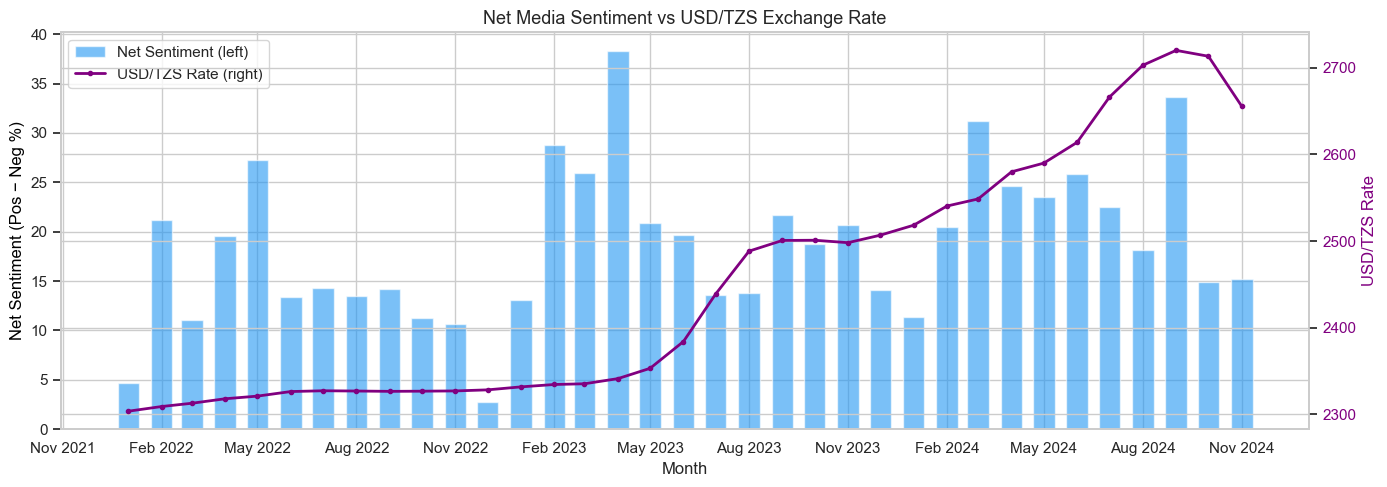

In [13]:
fig, ax1 = plt.subplots(figsize=(14, 5))

# Left axis: Net Sentiment
ax1.bar(df['Date'], df['Net_Sentiment'], width=20,
        color=[SENTIMENT_COLORS['Positive'] if v >= 0 else SENTIMENT_COLORS['Negative']
               for v in df['Net_Sentiment']], alpha=0.6, label='Net Sentiment (left)')
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.set_ylabel('Net Sentiment (Pos − Neg %)', color='black')

# Right axis: Exchange rate
ax2 = ax1.twinx()
ax2.plot(df['Date'], df['USD/TZS_Rate'], color='purple', linewidth=2,
         marker='o', markersize=3, label='USD/TZS Rate (right)')
ax2.set_ylabel('USD/TZS Rate', color='purple')
ax2.tick_params(axis='y', labelcolor='purple')

ax1.set_title('Net Media Sentiment vs USD/TZS Exchange Rate', fontsize=13)
ax1.set_xlabel('Month')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha='right')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

### 5.3 Scatter: Positive Sentiment vs Inflation

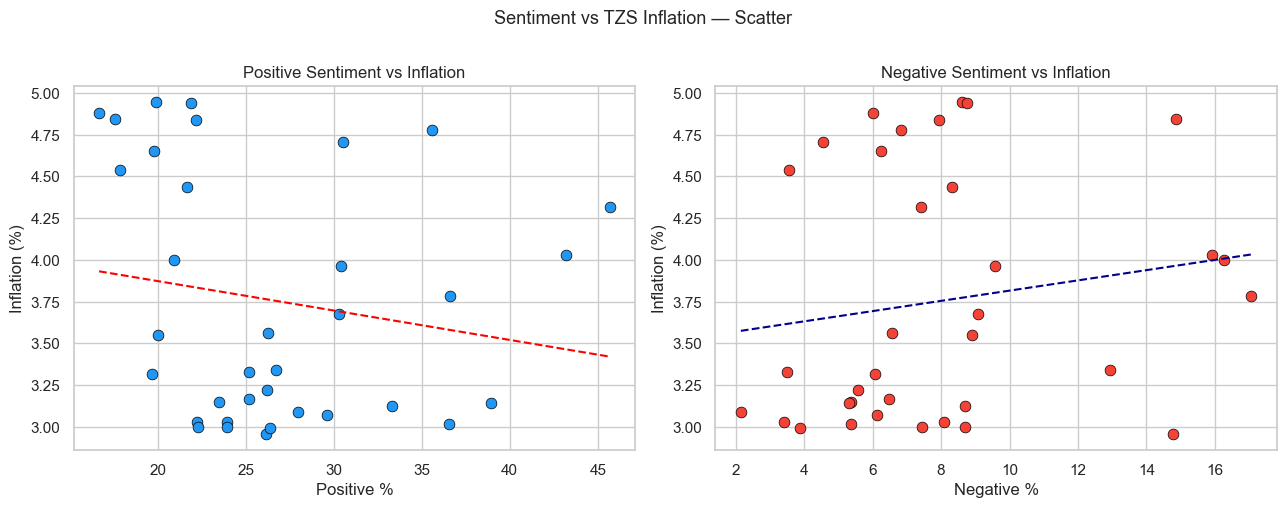

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Positive % vs Inflation
axes[0].scatter(df['Positive %'], df['Inflation %'],
                color=SENTIMENT_COLORS['Positive'], edgecolors='black', linewidth=0.5, s=60)
# Linear trend line
m, b = np.polyfit(df['Positive %'], df['Inflation %'], 1)
x_line = np.linspace(df['Positive %'].min(), df['Positive %'].max(), 50)
axes[0].plot(x_line, m * x_line + b, color='red', linewidth=1.5, linestyle='--')
axes[0].set_title('Positive Sentiment vs Inflation')
axes[0].set_xlabel('Positive %')
axes[0].set_ylabel('Inflation (%)')

# Right: Negative % vs Inflation
axes[1].scatter(df['Negative %'], df['Inflation %'],
                color=SENTIMENT_COLORS['Negative'], edgecolors='black', linewidth=0.5, s=60)
m2, b2 = np.polyfit(df['Negative %'], df['Inflation %'], 1)
x_line2 = np.linspace(df['Negative %'].min(), df['Negative %'].max(), 50)
axes[1].plot(x_line2, m2 * x_line2 + b2, color='darkblue', linewidth=1.5, linestyle='--')
axes[1].set_title('Negative Sentiment vs Inflation')
axes[1].set_xlabel('Negative %')
axes[1].set_ylabel('Inflation (%)')

plt.suptitle('Sentiment vs TZS Inflation — Scatter', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 5.4 Scatter: Sentiment vs USD/TZS Rate

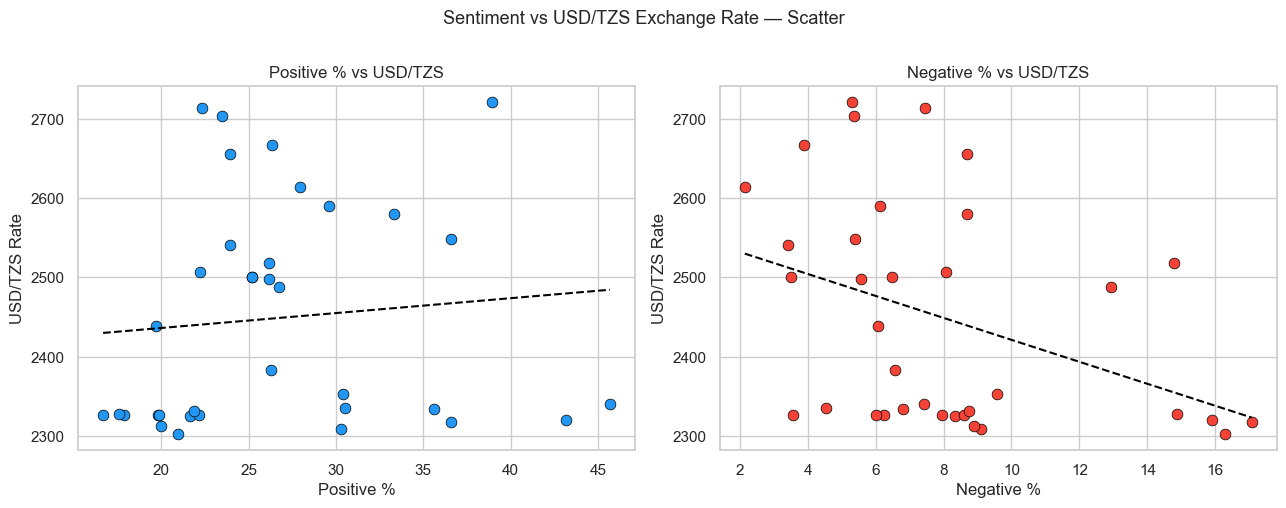

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, color, label in [
    (axes[0], 'Positive %', SENTIMENT_COLORS['Positive'], 'Positive % vs USD/TZS'),
    (axes[1], 'Negative %', SENTIMENT_COLORS['Negative'], 'Negative % vs USD/TZS')
]:
    ax.scatter(df[col], df['USD/TZS_Rate'], color=color,
               edgecolors='black', linewidth=0.5, s=60)
    m, b = np.polyfit(df[col], df['USD/TZS_Rate'], 1)
    x_line = np.linspace(df[col].min(), df[col].max(), 50)
    ax.plot(x_line, m * x_line + b, color='black', linewidth=1.5, linestyle='--')
    ax.set_title(label)
    ax.set_xlabel(col)
    ax.set_ylabel('USD/TZS Rate')

plt.suptitle('Sentiment vs USD/TZS Exchange Rate — Scatter', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 6. Correlation Analysis

### 6.1 Pearson Correlation Matrix (Heatmap)

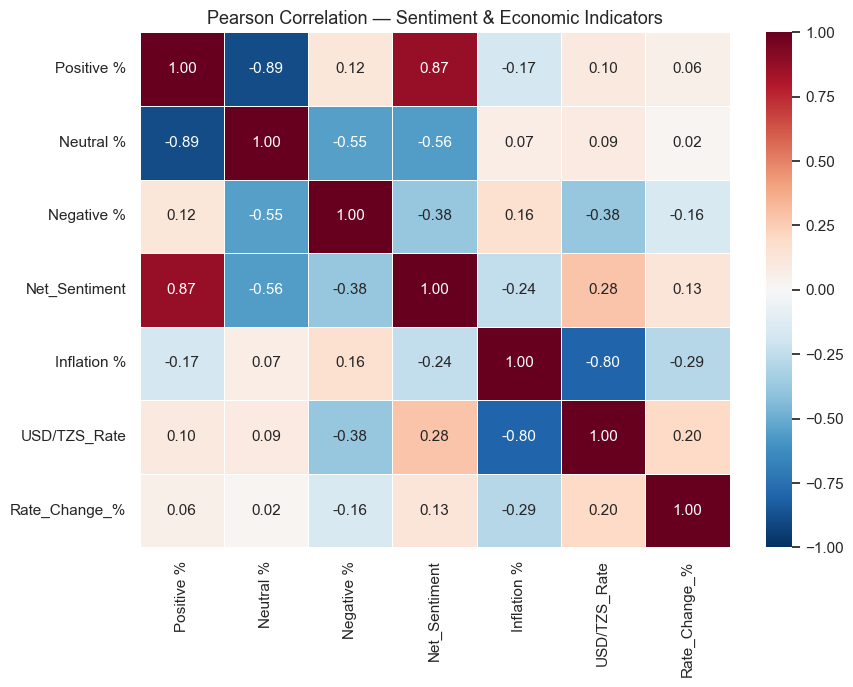


Correlation with Inflation %:
Negative %       0.162860
Neutral %        0.073640
Positive %      -0.174770
Net_Sentiment   -0.243832
Rate_Change_%   -0.286902
USD/TZS_Rate    -0.800506

Correlation with USD/TZS_Rate:
Net_Sentiment    0.281664
Rate_Change_%    0.196139
Positive %       0.097157
Neutral %        0.090873
Negative %      -0.383723
Inflation %     -0.800506


In [16]:
cols_of_interest = ['Positive %', 'Neutral %', 'Negative %',
                    'Net_Sentiment', 'Inflation %', 'USD/TZS_Rate', 'Rate_Change_%']

corr_matrix = df[cols_of_interest].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Pearson Correlation — Sentiment & Economic Indicators', fontsize=13)
plt.tight_layout()
plt.show()

print('\nCorrelation with Inflation %:')
print(corr_matrix['Inflation %'].drop('Inflation %').sort_values(ascending=False).to_string())
print('\nCorrelation with USD/TZS_Rate:')
print(corr_matrix['USD/TZS_Rate'].drop('USD/TZS_Rate').sort_values(ascending=False).to_string())

### 6.2 Lagged Correlation — Sentiment leading Economic Indicators
Tests whether **this month's sentiment** predicts **next month's** inflation/exchange rate change.

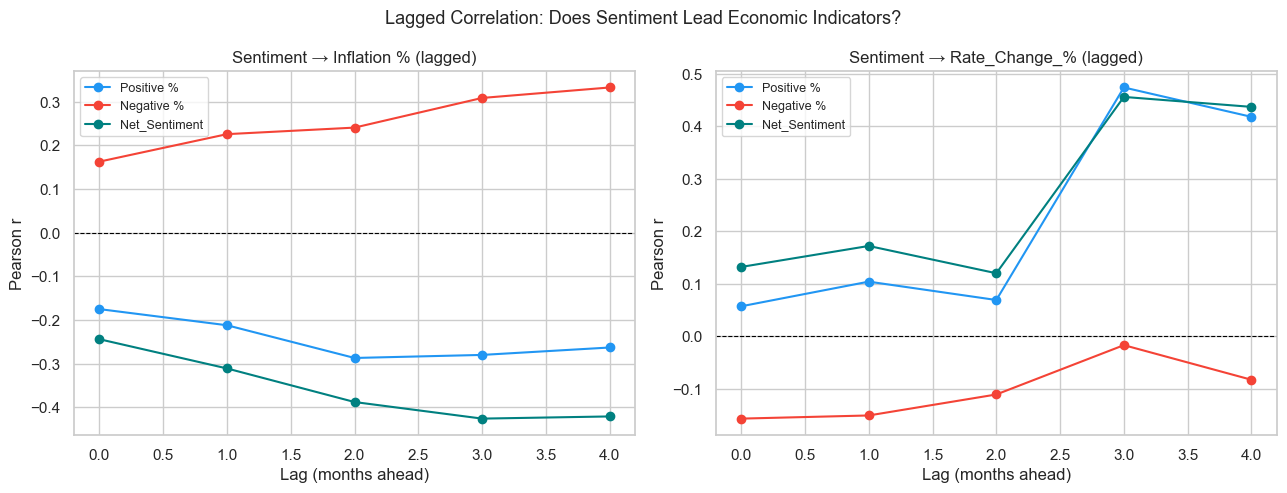

In [17]:
max_lag = 4
sentiment_cols = ['Positive %', 'Negative %', 'Net_Sentiment']
econ_cols = ['Inflation %', 'Rate_Change_%']

lag_results = []
for s_col in sentiment_cols:
    for e_col in econ_cols:
        for lag in range(0, max_lag + 1):
            shifted_econ = df[e_col].shift(-lag)  # future economic value
            valid = df[s_col].notna() & shifted_econ.notna()
            r = np.corrcoef(df.loc[valid, s_col], shifted_econ[valid])[0, 1]
            lag_results.append({'Sentiment': s_col, 'Economic': e_col,
                                 'Lag (months)': lag, 'Pearson r': round(r, 3)})

lag_df = pd.DataFrame(lag_results)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

colors_map = {'Positive %': SENTIMENT_COLORS['Positive'],
              'Negative %': SENTIMENT_COLORS['Negative'],
              'Net_Sentiment': 'teal'}

for ax, econ_col in zip(axes, econ_cols):
    subset = lag_df[lag_df['Economic'] == econ_col]
    for s_col in sentiment_cols:
        s_data = subset[subset['Sentiment'] == s_col]
        ax.plot(s_data['Lag (months)'], s_data['Pearson r'],
                marker='o', linewidth=1.5, label=s_col, color=colors_map[s_col])
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'Sentiment → {econ_col} (lagged)')
    ax.set_xlabel('Lag (months ahead)')
    ax.set_ylabel('Pearson r')
    ax.legend(fontsize=9)

plt.suptitle('Lagged Correlation: Does Sentiment Lead Economic Indicators?', fontsize=13)
plt.tight_layout()
plt.show()

---
## 7. Yearly Comparisons

### 7.1 Average Sentiment Breakdown by Year

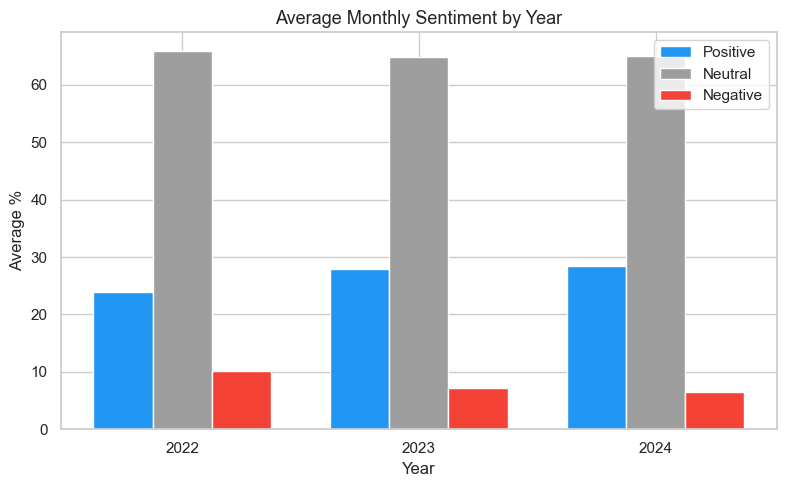

      Positive %  Neutral %  Negative %
Year                                   
2022       23.88      65.88       10.23
2023       27.96      64.85        7.19
2024       28.41      65.11        6.48


In [18]:
df['Year'] = df['Date'].dt.year
yearly = df.groupby('Year')[['Positive %', 'Neutral %', 'Negative %']].mean()

fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(yearly))
width = 0.25

ax.bar(x - width, yearly['Positive %'], width, label='Positive',
       color=SENTIMENT_COLORS['Positive'])
ax.bar(x,         yearly['Neutral %'],  width, label='Neutral',
       color=SENTIMENT_COLORS['Neutral'])
ax.bar(x + width, yearly['Negative %'], width, label='Negative',
       color=SENTIMENT_COLORS['Negative'])

ax.set_title('Average Monthly Sentiment by Year', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Average %')
ax.set_xticks(x)
ax.set_xticklabels(yearly.index)
ax.legend()

plt.tight_layout()
plt.show()

print(yearly.round(2))

### 7.2 Average Inflation and USD/TZS Rate by Year

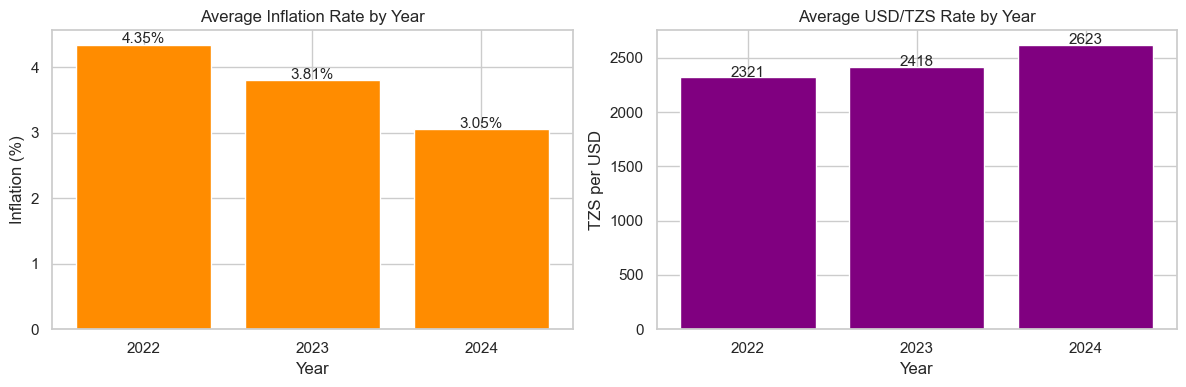

In [19]:
yearly_econ = df.groupby('Year')[['Inflation %', 'USD/TZS_Rate']].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(yearly_econ.index.astype(str), yearly_econ['Inflation %'],
            color='darkorange')
axes[0].set_title('Average Inflation Rate by Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Inflation (%)')
for i, v in enumerate(yearly_econ['Inflation %']):
    axes[0].text(i, v + 0.02, f'{v:.2f}%', ha='center')

axes[1].bar(yearly_econ.index.astype(str), yearly_econ['USD/TZS_Rate'],
            color='purple')
axes[1].set_title('Average USD/TZS Rate by Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('TZS per USD')
for i, v in enumerate(yearly_econ['USD/TZS_Rate']):
    axes[1].text(i, v + 5, f'{v:.0f}', ha='center')

plt.tight_layout()
plt.show()

---
## 8. Summary Statistics

In [20]:
print('='*60)
print('EF-02 PROJECT — DATASET SUMMARY')
print('='*60)
print(f"Period covered:        {df['YearMonth'].min()} → {df['YearMonth'].max()}")
print(f"Total months:          {len(df)}")
print(f"Total headlines:       {df['num_headlines'].sum():,}")
print()
print('--- Sentiment (average monthly %) ---')
print(f"  Positive:  {df['Positive %'].mean():.1f}%")
print(f"  Neutral:   {df['Neutral %'].mean():.1f}%   ← known labelling bias")
print(f"  Negative:  {df['Negative %'].mean():.1f}%")
print()
print('--- Economic Indicators ---')
print(f"  Avg Inflation:       {df['Inflation %'].mean():.2f}%")
print(f"  Inflation range:     {df['Inflation %'].min():.2f}% – {df['Inflation %'].max():.2f}%")
print(f"  USD/TZS start:       {df['USD/TZS_Rate'].iloc[0]:.0f}")
print(f"  USD/TZS end:         {df['USD/TZS_Rate'].iloc[-1]:.0f}")
print()
print('--- Correlation Highlights (Pearson r) ---')
r_pos_infl = df['Positive %'].corr(df['Inflation %'])
r_neg_infl = df['Negative %'].corr(df['Inflation %'])
r_net_usd  = df['Net_Sentiment'].corr(df['USD/TZS_Rate'])
r_pos_usd  = df['Positive %'].corr(df['USD/TZS_Rate'])
print(f"  Positive % ↔ Inflation:     r = {r_pos_infl:+.3f}")
print(f"  Negative % ↔ Inflation:     r = {r_neg_infl:+.3f}")
print(f"  Net Sentiment ↔ USD/TZS:   r = {r_net_usd:+.3f}")
print(f"  Positive % ↔ USD/TZS:      r = {r_pos_usd:+.3f}")
print('='*60)

EF-02 PROJECT — DATASET SUMMARY
Period covered:        2022-01 → 2024-11
Total months:          35
Total headlines:       3,776

--- Sentiment (average monthly %) ---
  Positive:  26.7%
  Neutral:   65.3%   ← known labelling bias
  Negative:  8.0%

--- Economic Indicators ---
  Avg Inflation:       3.75%
  Inflation range:     2.96% – 4.94%
  USD/TZS start:       2303
  USD/TZS end:         2656

--- Correlation Highlights (Pearson r) ---
  Positive % ↔ Inflation:     r = -0.175
  Negative % ↔ Inflation:     r = +0.163
  Net Sentiment ↔ USD/TZS:   r = +0.282
  Positive % ↔ USD/TZS:      r = +0.097
